In [1]:
import argparse
import numpy as np 
import pygmt
import time
import modokada as mo 
import modfallas as mf 
import matplotlib.pyplot as plt
from scipy.interpolate import interpn, interp1d,griddata,RegularGridInterpolator
from geographiclib.geodesic import Geodesic
import json
import gc 

In [2]:
# lat abajo, lon al lado
# ruta del archivo de la fosa
ruta_fosa = "../Slab/"
# archivo fosa ( primera columna: longitudes, segunda columna: latitudes)
arc_fosa  = ruta_fosa + "trench-chile.txt"
# carga de fosa usando funcion del modulo modfallas
lonfosa, latfosa  = mf.carga_fosa(arc_fosa)

directorio = "../Slab/"
# archivo de profundidad
proffile   = directorio + "sam_slab2_dep_02.23.18.xyz" # nombre del archivo de prof
slabprof   = np.genfromtxt(proffile, delimiter = ",") # se lee el archivo a un array
# archivo de dip
dipfile    = directorio + "sam_slab2_dip_02.23.18.xyz" # nombre del archivo de dip
slabdip    = np.genfromtxt(dipfile, delimiter = ",") # se lee el archivo a un array
# archivo de strike
strfile    = directorio + "sam_slab2_str_02.23.18.xyz"
slabstrike = np.genfromtxt(strfile, delimiter = ",") # se lee el archivo a un array
## archivo de rake
rakefile   = directorio + "sam_rake.xyz"
slabrake   = np.genfromtxt(rakefile, delimiter = ",")


# las longitudes estan en formato 0 - 360, se cambian a -180 - 180
slabprof[:,0]   = slabprof[:,0] - 360
slabdip[:,0]    = slabdip[:,0] - 360
slabstrike[:,0] = slabstrike[:,0] - 360

# longitudes y latitudes del modelo
lonmod = slabprof[:,0]
latmod = slabprof[:,1]
# longitudes y latitudes unicas del modelo
lonunimod = np.unique(lonmod) # x
latunimod = np.unique(latmod) # y
# se grillan los arrays

In [23]:
latmodgrid, lonmodgrid = np.meshgrid(np.flip(latunimod),lonunimod) # X, Y datos grillados para graficar modelo completo
print(latmodgrid)
print(lonmodgrid)
print(profmod.shape)

[[ 15.    14.95  14.9  ... -48.9  -48.95 -49.  ]
 [ 15.    14.95  14.9  ... -48.9  -48.95 -49.  ]
 [ 15.    14.95  14.9  ... -48.9  -48.95 -49.  ]
 ...
 [ 15.    14.95  14.9  ... -48.9  -48.95 -49.  ]
 [ 15.    14.95  14.9  ... -48.9  -48.95 -49.  ]
 [ 15.    14.95  14.9  ... -48.9  -48.95 -49.  ]]
[[-86.   -86.   -86.   ... -86.   -86.   -86.  ]
 [-85.95 -85.95 -85.95 ... -85.95 -85.95 -85.95]
 [-85.9  -85.9  -85.9  ... -85.9  -85.9  -85.9 ]
 ...
 [-57.1  -57.1  -57.1  ... -57.1  -57.1  -57.1 ]
 [-57.05 -57.05 -57.05 ... -57.05 -57.05 -57.05]
 [-57.   -57.   -57.   ... -57.   -57.   -57.  ]]
(581, 1281)


In [20]:

# profundidades, dips y strikes del modelo
profmod   = slabprof[:,2]*-1000. # metros positivos hacia abajo
dipmod    = slabdip[:,2]
strikemod = slabstrike[:,2]
# se grillan los datos
profmod   = np.reshape(profmod,np.shape(lonmodgrid))
dipmod    = np.reshape(dipmod,np.shape(lonmodgrid))
strikemod = np.reshape(strikemod,np.shape(lonmodgrid))

In [31]:
inter_profmod  = RegularGridInterpolator((lonmodgrid[0,:],latmodgrid[:,0]),profmod,method='nearest') # profundidad grillada con 0 en lugar de nan
inter_dipmod = RegularGridInterpolator((lonmodgrid[0,:],latmodgrid[:,0]),dipmod,method='nearest') # dip grillado con 0 en lugar de nan
inter_strikemod = RegularGridInterpolator((lonmodgrid[0,:],latmodgrid[:,0]),strikemod,method='nearest') # strike grillado con 0 en lugar de nan

ValueError: The points in dimension 0 must be strictly ascending or descending

In [7]:
import numpy as np
rng = np.random.default_rng()
points = rng.random((1000, 2))

[[0.1220039  0.89258737]
 [0.82175808 0.48873815]
 [0.78195882 0.78745051]
 ...
 [0.51442077 0.06743963]
 [0.16345239 0.69128155]
 [0.29404479 0.80481883]]


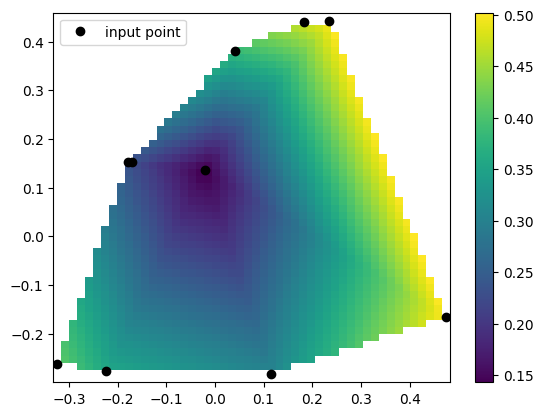

In [9]:
from scipy.interpolate import LinearNDInterpolator

import numpy as np

import matplotlib.pyplot as plt

rng = np.random.default_rng()

x = rng.random(10) - 0.5

y = rng.random(10) - 0.5

z = np.hypot(x, y)

X = np.linspace(min(x), max(x))

Y = np.linspace(min(y), max(y))

X, Y = np.meshgrid(X, Y)  # 2D grid for interpolation

interp = LinearNDInterpolator(list(zip(x, y)), z)

Z = interp(X, Y)

plt.pcolormesh(X, Y, Z, shading='auto')

plt.plot(x, y, "ok", label="input point")

plt.legend()

plt.colorbar()

plt.axis("equal")

plt.show()